In [16]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import networkx as nx
import tifffile as tiff

from pyvis.network import Network

from skimage.morphology import skeletonize
from skimage.util import invert
from skimage import io

from matplotlib.collections import PatchCollection
from matplotlib.patches import Circle

from scipy.interpolate import griddata

import os
import database

from config import microns_per_pixel, main_image_path, processed_path
from pathlib import Path

import analysis

C:\Users\isabe\Documents\work\systems bio\modelling vasculogenesis\python\data\processed\skeleton_networks
C:\Users\isabe\Documents\work\systems bio\modelling vasculogenesis\python\data\raw\main\hh10_n1 plain_scaled.jpg
135.0


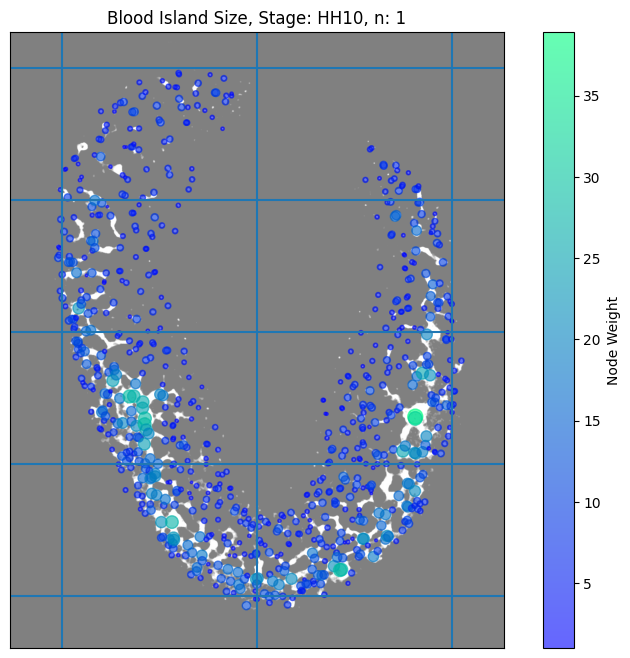

C:\Users\isabe\Documents\work\systems bio\modelling vasculogenesis\python\data\raw\main\hh10_n2 plain_scaled.jpg
414.0


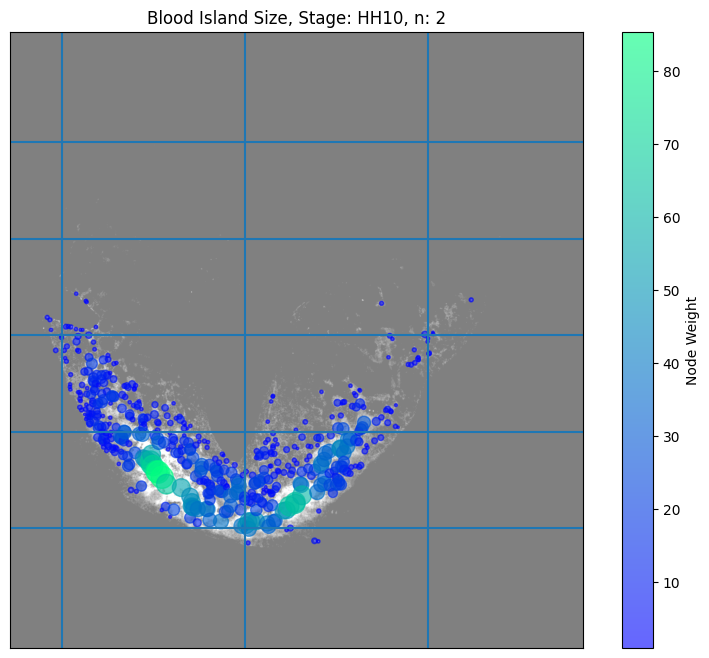

C:\Users\isabe\Documents\work\systems bio\modelling vasculogenesis\python\data\raw\main\hh10_n3 plain_scaled.jpg
248.0


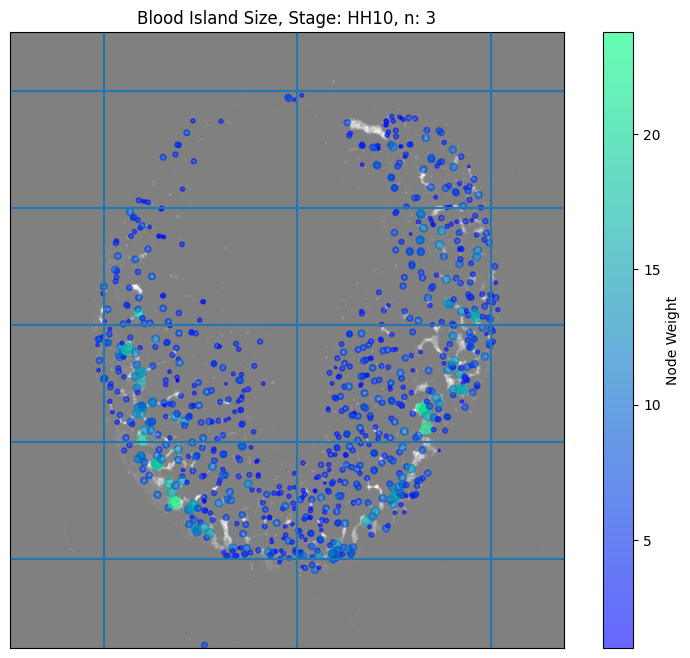

C:\Users\isabe\Documents\work\systems bio\modelling vasculogenesis\python\data\raw\main\hh11_n1 plain_scaled.jpg
9.0


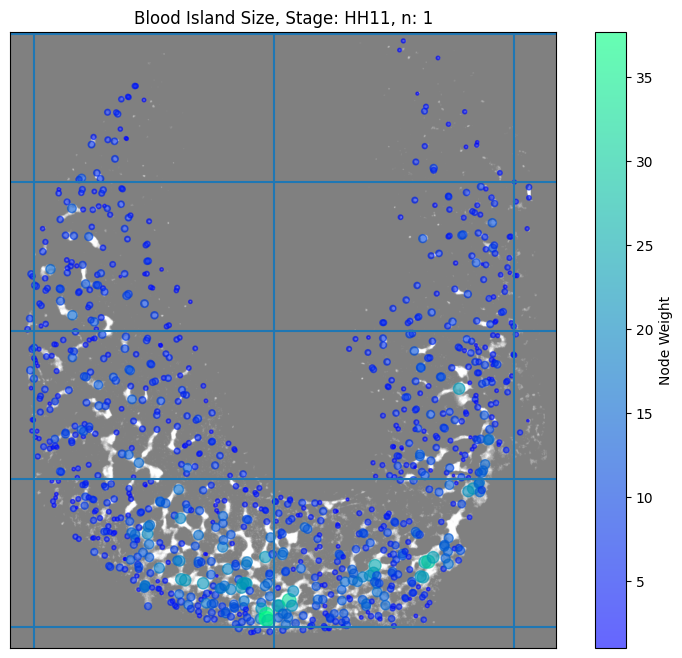

C:\Users\isabe\Documents\work\systems bio\modelling vasculogenesis\python\data\raw\main\hh11_n2 plain_scaled.jpg
120.0


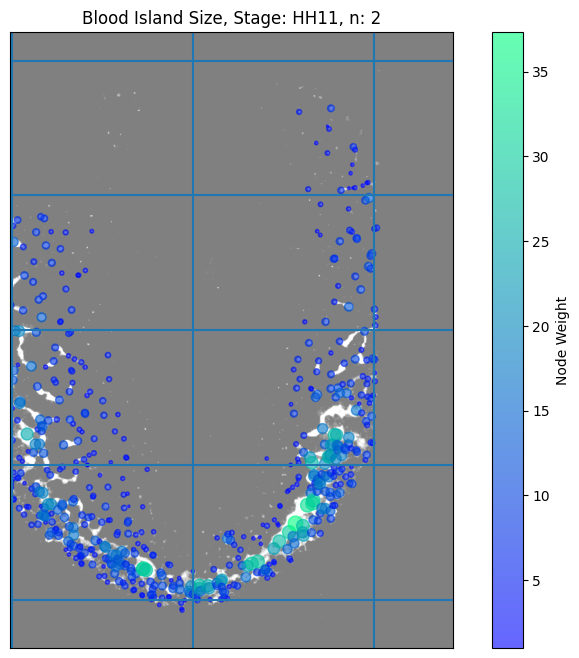

C:\Users\isabe\Documents\work\systems bio\modelling vasculogenesis\python\data\raw\main\hh12_n1 plain_scaled.jpg
44.0


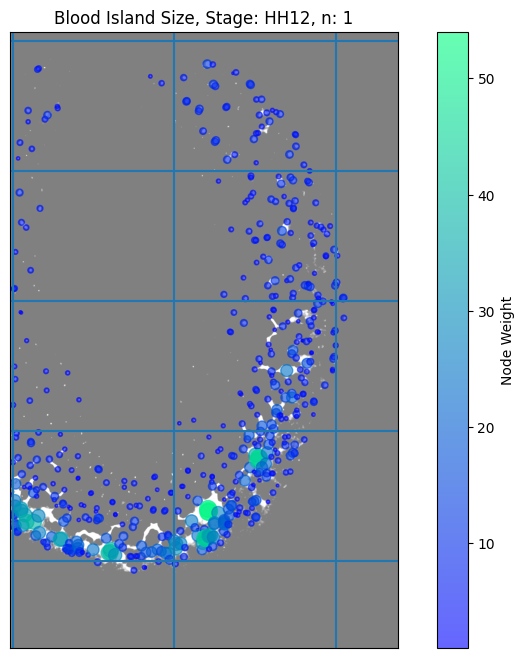

In [ ]:
nrows = 4
ncolumns = 2
nodes_data = pd.DataFrame(columns=["Stage","n","Row","Column","Number of Nodes","Nodes Degree"])
collected_data = []

nodes_path = processed_path / "skeleton_networks"
for file_name in os.listdir(nodes_path):
        #Get embryo ID
        embryo_ID, end = file_name.split("_")
        embryo_ID = int(embryo_ID)
        if end=="nodes.csv":
            nodes = pd.read_csv(nodes_path / f"{embryo_ID}_nodes.csv", index_col = 0)
            adj = pd.read_csv(nodes_path / f"{embryo_ID}_adj.csv", index_col = 0)

            #split into grid regions
            xmin = nodes["x"].quantile(0.01)
            xmax = nodes["x"].quantile(0.99)
            #ymin = nodes["y"].quantile(0.01)
            ymax = nodes["y"].quantile(0.99)

            metadata_df = database.initialise_metadata()
            ymin = metadata_df.loc[embryo_ID,"Anterior_Y"]/microns_per_pixel
            stage = int(metadata_df.loc[embryo_ID,"Stage"])
            n = int(metadata_df.loc[embryo_ID,"n"])
            condition = metadata_df.loc[embryo_ID,"Condition"]

            if pd.isna(condition):
                image = cv2.imread(main_image_path / f'hh{stage}_n{n} plain_scaled.jpg')
            else:
                image = cv2.imread(main_image_path / f'hh{stage}_n{n}_{condition} plain_scaled.jpg')

            height = len(image)
            width = len(image[0])

            print(ymin)
            col_lines = np.linspace(xmin,xmax,ncolumns+1)
            row_lines = np.linspace(ymin,ymax,nrows+1)

            nodes = analysis.calc_degrees(nodes,adj)

            #if stage == 5 and n==0:
            if 1==1:
                fig, ax = plt.subplots(figsize=(10, 8))
                #plot grid lines
                ax.hlines(row_lines,0,width)
                ax.vlines(col_lines,0,height)

                #plot iamge
                ax.imshow(image, cmap=plt.cm.gray,alpha=0.5)

                #plot nodes
                #should be x4? pixel to micron ratio?
                scatter = ax.scatter(nodes['x'], nodes['y'], c=nodes['weight'], s=nodes['weight']*3, alpha=0.6, label='Nodes',cmap="winter")
                plt.colorbar(scatter, label="Node Weight")
                ax.get_xaxis().set_visible(False)
                ax.get_yaxis().set_visible(False)

                ax.set_xlim(0,width)
                ax.set_ylim(height,0)
                plt.title(f"Blood Island Size, Stage: HH{stage}, n: {n}")
                plt.show()

            for c in range(ncolumns):
                for r in range(nrows):
                    # Ensure lower bound is strictly smaller than upper bound for .between()
                    x_lower = min(col_lines[c], col_lines[c+1])
                    x_upper = max(col_lines[c], col_lines[c+1])
                    
                    y_lower = min(row_lines[r], row_lines[r+1])
                    y_upper = max(row_lines[r], row_lines[r+1])
                    nodes_region = nodes[nodes["x"].between(x_lower,x_upper) & nodes["y"].between(y_lower,y_upper)]
                    

                    num_nodes = len(nodes_region)
                    # Avoid 'NaN' or warnings if a grid region has absolutely zero nodes
                    avg_degree = np.mean(nodes_region["degree"]) if num_nodes > 0 else 0

                    avg_weight = np.mean(nodes_region["weight"]) if num_nodes > 0 else 0
                    
                    # Append the data as a dictionary
                    collected_data.append({
                        "Embryo_ID": embryo_ID,
                        "Stage": stage,
                        "Condition": condition,
                        "n": n,
                        "Row": r,
                        "Column": c,
                        "Number of Nodes": num_nodes,
                        "Nodes Degree": avg_degree,
                        "Nodes Weight": avg_weight
                    })
#todo: save as csv?
nodes_data=pd.DataFrame(collected_data)



    Embryo_ID  Stage  Condition  n  Row  Column  Number of Nodes  \
0          23     10        NaN  1    0       0               77   
1          23     10        NaN  1    1       0               78   
2          23     10        NaN  1    2       0              115   
3          23     10        NaN  1    3       0              120   
4          23     10        NaN  1    0       1               18   
5          23     10        NaN  1    1       1               62   
6          23     10        NaN  1    2       1              109   
7          23     10        NaN  1    3       1              151   
8          24     10        NaN  2    0       0                0   
9          24     10        NaN  2    1       0               10   
10         24     10        NaN  2    2       0              130   
11         24     10        NaN  2    3       0              141   
12         24     10        NaN  2    0       1                0   
13         24     10        NaN  2    1       1 

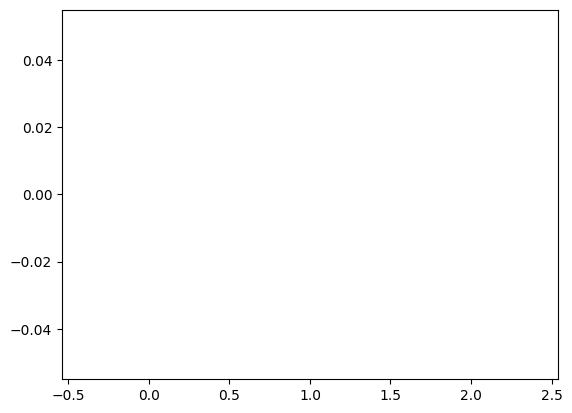

In [ ]:
print(nodes_data)
#todo: fix this
stages = pd.unique(nodes_data["Stage"].values)

for i in stages:
    stage_data = nodes_data[nodes_data["Stage"]==i]

    left_posterior = stage_data[ (stage_data["Row"]==0) & (stage_data["Column"]==0)]
    right_posterior = stage_data[ (stage_data["Row"]==0) & (stage_data["Column"]==1)]

    left_anterior = stage_data[ (stage_data["Row"]==1) & (stage_data["Column"]==0)]
    right_anterior = stage_data[ (stage_data["Row"]==1) & (stage_data["Column"]==1)]


    print(left_anterior)

    plt.bar(range(len(left_posterior)),left_posterior["Nodes Degree"].mean())
    print(left_posterior)

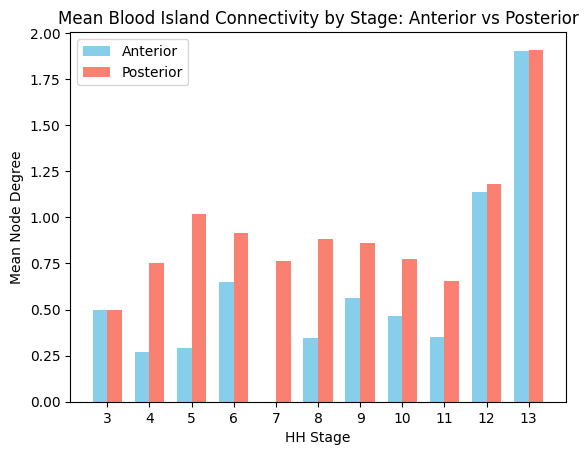

In [ ]:
#designed for n=2 rows only
mean_degree_anterior = []
mean_degree_posterior = []

for i in stages:
    stage_data = nodes_data[nodes_data["Stage"]==i]

    posterior = stage_data[ (stage_data["Row"]==1)]

    anterior = stage_data[ (stage_data["Row"]==0)]

    mean_degree_anterior.append(anterior["Nodes Degree"].mean())
    mean_degree_posterior.append(posterior["Nodes Degree"].mean())

x = np.arange(len(stages))
width = 0.35  

# 3. Plot both sets of bars, shifting them left and right of the center point
# x - width/2 shifts it left, x + width/2 shifts it right
plt.bar(x - width/2, mean_degree_anterior, width, label='Anterior', color='skyblue')
plt.bar(x + width/2, mean_degree_posterior, width, label='Posterior', color='salmon')
plt.xlabel('HH Stage')
plt.ylabel('Mean Node Degree')
plt.title('Mean Blood Island Connectivity by Stage: Anterior vs Posterior')
plt.xticks(x, stages)
plt.legend()

   Stage  n  Row  Column  Number of Nodes  Nodes Degree  Nodes Weight
0      3  0    0       0                4      1.000000      7.193977
1      3  0    1       0                2      1.000000      4.736068
2      3  0    2       0                2      0.000000      2.920810
3      3  0    3       0               12      0.416667      3.398824
4      3  0    0       1                1      0.000000      2.000000
5      3  0    1       1                0      0.000000      0.000000
6      3  0    2       1                0      0.000000      0.000000
7      3  0    3       1               19      0.368421      4.006436
    Stage  n  Row  Column  Number of Nodes  Nodes Degree  Nodes Weight
8       4  0    0       0                0      0.000000      0.000000
9       4  0    1       0               19      0.736842      2.930011
10      4  0    2       0               53      0.962264      4.464653
11      4  0    3       0               55      0.945455      4.746410
12      4  0   

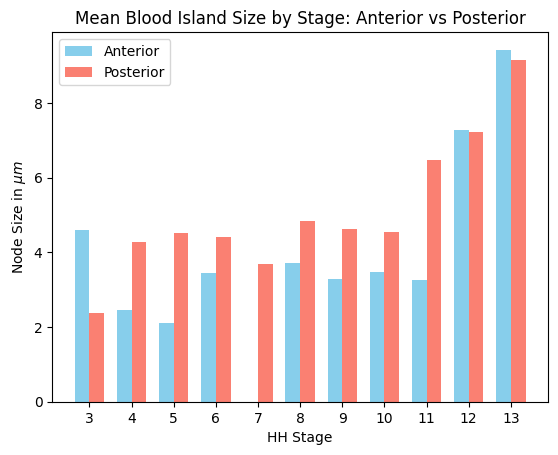

In [ ]:
#designed for n=2 rows only
mean_weight_anterior = []
mean_weight_posterior = []


for i in stages:
    stage_data = nodes_data[nodes_data["Stage"]==i]
    print(stage_data)

    posterior = stage_data[ (stage_data["Row"]==1)]

    anterior = stage_data[ (stage_data["Row"]==0)]
    mean_weight_anterior.append(anterior["Nodes Weight"].mean())
    mean_weight_posterior.append(posterior["Nodes Weight"].mean())

x = np.arange(len(stages))
width = 0.35  
# 3. Plot both sets of bars, shifting them left and right of the center point
# x - width/2 shifts it left, x + width/2 shifts it right
plt.bar(x-width/2, mean_weight_anterior, width, label='Anterior', color='skyblue')
plt.bar(x+width/2, mean_weight_posterior, width, label='Posterior', color='salmon')
plt.xlabel('HH Stage')
plt.ylabel('Node Size in $\mu m$')
plt.title('Mean Blood Island Size by Stage: Anterior vs Posterior')
plt.xticks(x, stages)
plt.legend()

[[-0.175       0.825       1.825       2.825       3.825       4.825
   5.825       6.825       7.825       8.825       9.825     ]
 [-0.05833333  0.94166667  1.94166667  2.94166667  3.94166667  4.94166667
   5.94166667  6.94166667  7.94166667  8.94166667  9.94166667]
 [ 0.05833333  1.05833333  2.05833333  3.05833333  4.05833333  5.05833333
   6.05833333  7.05833333  8.05833333  9.05833333 10.05833333]
 [ 0.175       1.175       2.175       3.175       4.175       5.175
   6.175       7.175       8.175       9.175      10.175     ]]


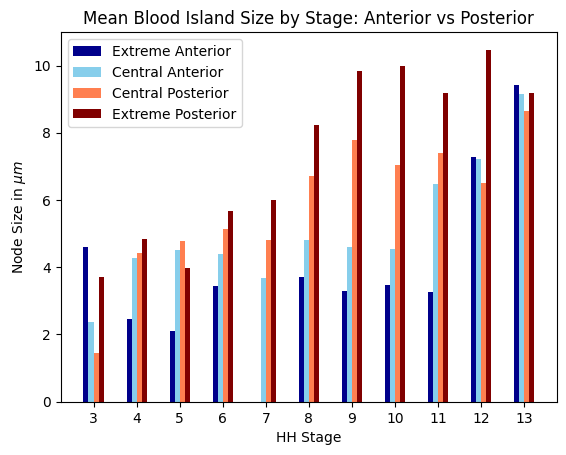

In [ ]:
#designed for n>2 rows
col_labels = ["Left", "Right"]
row_labels = ["Extreme Anterior", "Central Anterior","Central Posterior", "Extreme Posterior"]
mean_weights = pd.DataFrame(columns=row_labels,index=stages)

for i in stages:
    all_row_data = []
    for j in range(nrows):
        stage_data = nodes_data[nodes_data["Stage"]==i]

        current_row = stage_data[ (stage_data["Row"]==j)]

        mean_weight_current = current_row["Nodes Weight"].mean()

        label = row_labels[j]

        mean_weights.loc[i,label] = mean_weight_current
        #mean_weight_posterior.append(posterior["Nodes Weight"].mean())

x = np.arange(len(stages))
width = 0.35 
positions = np.linspace(x-width/2,x+width/2,nrows) 
print(positions)
colours = ["darkblue","skyblue","coral","maroon"]
for j in range(nrows):
    label = row_labels[j]
    plt.bar(positions[j], mean_weights[label], width/(nrows-1), label=label, color=colours[j])


# 3. Plot both sets of bars, shifting them left and right of the center point
# x - width/2 shifts it left, x + width/2 shifts it right
#plt.bar(x-width/2, mean_weight_anterior, width, label='Anterior', color='skyblue')
#plt.bar(x+width/2, mean_weight_posterior, width, label='Posterior', color='salmon')
plt.xlabel('HH Stage')
plt.ylabel('Node Size in $\mu m$')
plt.title('Mean Blood Island Size by Stage: Anterior vs Posterior')
plt.xticks(x, stages)
plt.legend()

     Stage  n  Row  Column  Number of Nodes  Nodes Degree  Nodes Weight
104     13  0    0       0              663      1.987934      9.270163
105     13  0    1       0              865      1.788439      8.791305
106     13  0    0       1              818      1.965770      9.379839
107     13  0    1       1             1166      1.811321      8.606713
108     13  1    0       0              518      1.901544      9.463785
109     13  1    1       0              884      1.813348      9.450355
110     13  1    0       1              516      1.786822      8.938293
111     13  1    1       1              879      1.739477      8.607993


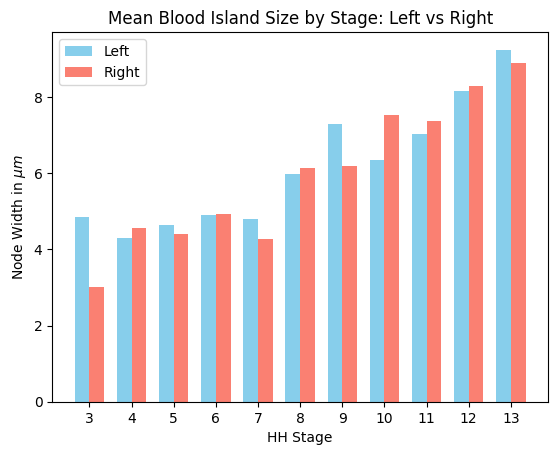

In [11]:
mean_weight_left= []
mean_weight_right = []
print(stage_data)

for i in stages:
    stage_data = nodes_data[nodes_data["Stage"]==i]

    posterior = stage_data[ (stage_data["Column"]==1)]

    anterior = stage_data[ (stage_data["Column"]==0)]
    mean_weight_left.append(anterior["Nodes Weight"].mean())
    mean_weight_right.append(posterior["Nodes Weight"].mean())

x = np.arange(len(stages))
width = 0.35  
# 3. Plot both sets of bars, shifting them left and right of the center point
# x - width/2 shifts it left, x + width/2 shifts it right
plt.bar(x-width/2, mean_weight_left, width, label='Left', color='skyblue')
plt.bar(x+width/2, mean_weight_right, width, label='Right', color='salmon')
plt.xlabel('HH Stage')
plt.ylabel('Node Width in $\mu m$')
plt.title('Mean Blood Island Size by Stage: Left vs Right')
plt.xticks(x, stages)
plt.legend()

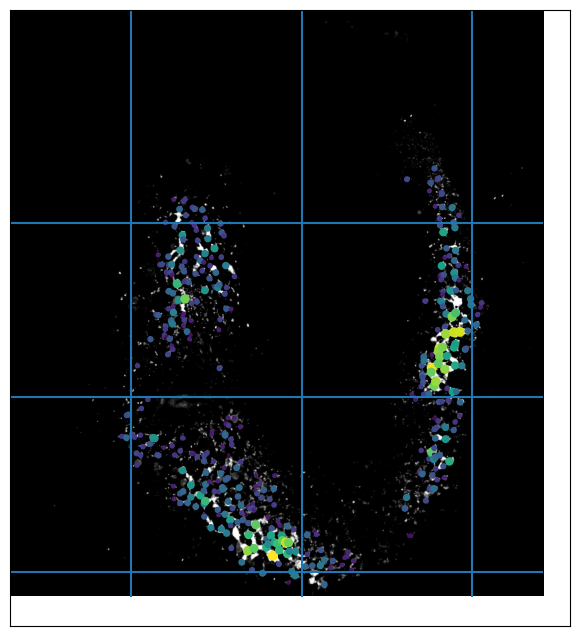

In [33]:
stage = 5
stage_id = stages.index(stage)
n=0
nodes = nodes_all_stages[stage_id][n].copy()
adj = adj_all_stages[stage_id][n].copy()

#append number of neighbours information
nodes = calc_degrees(adj,nodes)
#standardise the rotation eg. if embryo is diagonal
nodes = rotate_all_nodes(nodes,stage,n+1)



#plot rtoated iamge
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.logical_and(rotated_images["Stage"]==stage, rotated_images["n"]==n)
image = rotated_images[mask]["image"].iloc[0]

height = len(image)
width = len(image[0])
ax.imshow(image, cmap=plt.cm.gray)

xmin = nodes["x"].quantile(0.01)
xmax = nodes["x"].quantile(0.99)
#ymin = nodes["y"].quantile(0.01)
ymax = nodes["y"].quantile(0.99)

ymin_unrot = data_row["AnteriorY"].iloc[0]/4
_,ymin = rotate_nodes(data_row["AnteriorX"].iloc[0]/4,ymin_unrot,theta,width,height)

col_lines = np.linspace(xmin,xmax,ncolumns+1)
row_lines = np.linspace(ymin,ymax,nrows+1)



#plot grid lines
ax.hlines(row_lines,0,width)
ax.vlines(col_lines,0,height)


#plot nodes
scatter = ax.scatter(nodes['x'], nodes['y'], c=nodes['weight'], s=nodes["weight"]*3, alpha=1, label='Nodes')
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.show()

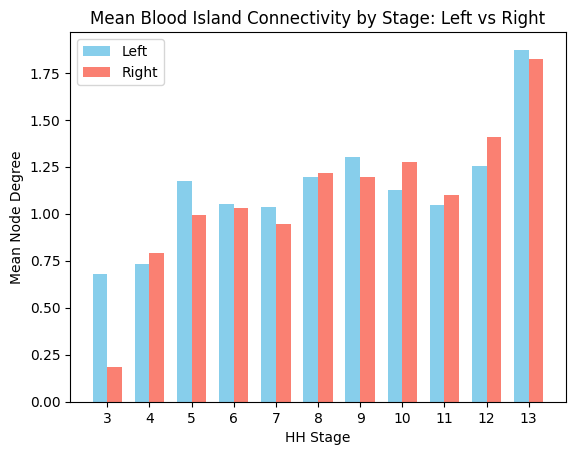

In [9]:
mean_degree_left = []
mean_degree_right = []

for i in stages:
    stage_data = nodes_data[nodes_data["Stage"]==i]

    right = stage_data[ (stage_data["Column"]==1)]

    left = stage_data[ (stage_data["Column"]==0)]

    mean_degree_left.append(left["Nodes Degree"].mean())
    mean_degree_right.append(right["Nodes Degree"].mean())

x = np.arange(len(stages))
width = 0.35  

# 3. Plot both sets of bars, shifting them left and right of the center point
# x - width/2 shifts it left, x + width/2 shifts it right
plt.bar(x - width/2, mean_degree_left, width, label='Left', color='skyblue')
plt.bar(x + width/2, mean_degree_right, width, label='Right', color='salmon')
plt.xlabel('HH Stage')
plt.ylabel('Mean Node Degree')
plt.title('Mean Blood Island Connectivity by Stage: Left vs Right')
plt.xticks(x, stages)
plt.legend()

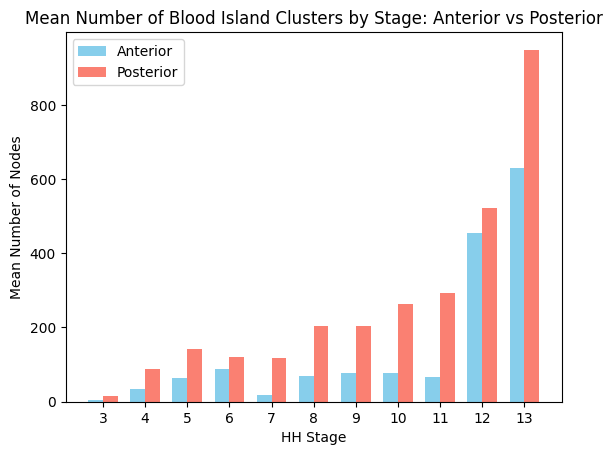

In [10]:
mean_num_anterior = []
mean_num_posterior = []
for i in stages:
    stage_data = nodes_data[nodes_data["Stage"]==i]

    posterior = stage_data[ (stage_data["Row"]==1)]

    anterior = stage_data[ (stage_data["Row"]==0)]

    mean_num_anterior.append(anterior["Number of Nodes"].mean())
    mean_num_posterior.append(posterior["Number of Nodes"].mean())

x = np.arange(len(stages))
width = 0.35  

# 3. Plot both sets of bars, shifting them left and right of the center point
# x - width/2 shifts it left, x + width/2 shifts it right
plt.bar(x - width/2, mean_num_anterior, width, label='Anterior', color='skyblue')
plt.bar(x + width/2, mean_num_posterior, width, label='Posterior', color='salmon')
plt.xlabel('HH Stage')
plt.ylabel('Mean Number of Nodes')
plt.title('Mean Number of Blood Island Clusters by Stage: Anterior vs Posterior')
plt.xticks(x, stages)
plt.legend()

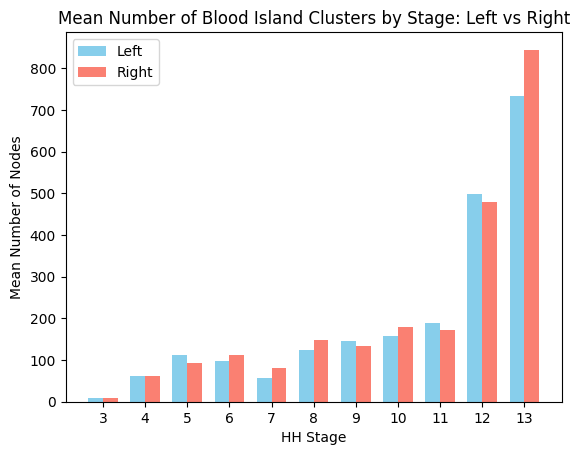

In [11]:
mean_degree_left = []
mean_degree_right = []

for i in stages:
    stage_data = nodes_data[nodes_data["Stage"]==i]

    right = stage_data[ (stage_data["Column"]==1)]

    left = stage_data[ (stage_data["Column"]==0)]

    mean_degree_left.append(left["Number of Nodes"].mean())
    mean_degree_right.append(right["Number of Nodes"].mean())

x = np.arange(len(stages))
width = 0.35  

# 3. Plot both sets of bars, shifting them left and right of the center point
# x - width/2 shifts it left, x + width/2 shifts it right
plt.bar(x - width/2, mean_degree_left, width, label='Left', color='skyblue')
plt.bar(x + width/2, mean_degree_right, width, label='Right', color='salmon')
plt.xlabel('HH Stage')
plt.ylabel('Mean Number of Nodes')
plt.title('Mean Number of Blood Island Clusters by Stage: Left vs Right')
plt.xticks(x, stages)
plt.legend()